# Ensemble Methods on Brainvita (From Scratch)

This notebook uses custom `rice_ml` ensemble models on Brainvita board-state features. We compare simple baselines, bagging, random forests, and voting for the high-mobility classification task, then use a random forest regressor to predict the raw number of legal moves.

The guiding question is whether combining multiple weak or moderately strong learners gives a more stable Brainvita model than relying on a single tree or a single linear decision boundary.

## Learning Objectives

1. Explain why bagging and random forests reduce variance relative to a single tree.
2. Use Brainvita features to classify high-mobility states with custom ensemble classifiers.
3. Compare majority-class, single-tree, bagging, random-forest, and voting baselines.
4. Evaluate classification with accuracy, precision, recall, F1, confusion matrices, and ROC-AUC when probabilities are available.
5. Fit a custom random forest regressor for `num_legal_moves` and compare it against a mean predictor.


## 1. Intuition

A single decision tree can be powerful, but it is often unstable: small changes in the training data can produce different splits. Ensembles reduce this instability by combining several models.

- **Bagging** trains many learners on bootstrap samples and averages their votes.
- **Random Forests** add feature subsampling, which decorrelates trees and usually improves generalization.
- **Voting** combines different model families, letting each model contribute a decision or probability estimate.

For classification, the ensemble prediction can be viewed as a majority vote:

$$
\hat{y} = \operatorname{mode}\left(h_1(x), h_2(x), \ldots, h_B(x)\right)
$$

For regression, random forests average tree predictions:

$$
\hat{y} = \frac{1}{B}\sum_{b=1}^B h_b(x)
$$



## Dataset and Targets

The Brainvita dataset contains engineered summaries of peg-solitaire board states. We use the same curated feature set as the other supervised-learning notebooks: peg density, jumpable pegs, mobility ratio, cluster summaries, adjacency statistics, center of mass, spread, reachability, and board dimensions.

This notebook uses two targets:

- **Classification:** `num_legal_moves >= 3`, interpreted as a high-mobility board state.
- **Regression:** `num_legal_moves`, the raw count of legal moves.

Tree-based ensembles do not require feature standardization, so we keep the raw numeric features. To keep notebook runtime reasonable, we sample up to 8,000 rows with a fixed random seed while preserving the same train/test methodology.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root(start='.'):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / 'src' / 'rice_ml').exists() and (q / 'data' / 'brainvita_dataset.csv').exists():
            return q
    raise FileNotFoundError('Could not locate repository root')


ROOT = find_repo_root('.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_PATH = ROOT / 'data' / 'brainvita_dataset.csv'
print('Repo root:', ROOT)
print('Dataset path:', DATA_PATH)

from rice_ml.supervised_learning import (
    BaggingClassifier, VotingClassifier, RandomForestClassifier, RandomForestRegressor,
    DecisionTreeClassifier, KNNClassifier
)

Repo root: /Users/LakshSarda/Desktop/CMOR_438_Repository
Dataset path: /Users/LakshSarda/Desktop/CMOR_438_Repository/data/brainvita_dataset.csv


In [2]:
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(',')

exclude_cols = {
    'num_legal_moves',
    'board_state',
    'best_move_r1', 'best_move_c1', 'best_move_r2', 'best_move_c2',
    'worst_move_r1', 'worst_move_c1', 'worst_move_r2', 'worst_move_c2',
}

raw_feature_cols = [c for c in header if c not in exclude_cols]
selected_cols = raw_feature_cols + ['num_legal_moves']
selected_idx = [header.index(c) for c in selected_cols]
arr = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1, usecols=selected_idx, dtype=float)

X_raw = arr[:, :-1]
y_reg = arr[:, -1]
y_bin = (y_reg >= 3.0).astype(int)

preferred_features = ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']
feature_cols = [c for c in preferred_features if c in raw_feature_cols]
keep_idx = [raw_feature_cols.index(c) for c in feature_cols]
X = X_raw[:, keep_idx]

# Reproducible subset for notebook runtime while preserving methodology.
rng_sample = np.random.default_rng(42)
sample_n = min(8000, X.shape[0])
sel = rng_sample.choice(X.shape[0], size=sample_n, replace=False)
X = X[sel]
y_reg = y_reg[sel]
y_bin = y_bin[sel]
print('Using sampled rows for notebook execution:', X.shape[0])

print(f'Rows: {X.shape[0]:,} | Features: {X.shape[1]}')
print('Positive class rate (num_legal_moves >= 3):', float(y_bin.mean()))
print('Features used:', feature_cols)


Using sampled rows for notebook execution: 8000
Rows: 8,000 | Features: 15
Positive class rate (num_legal_moves >= 3): 0.28575
Features used: ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']


## 2. Classification Ensembles (`num_legal_moves >= 3`)

We first predict whether a state has at least three legal moves. The comparison starts with a majority-class baseline and a single decision tree, then moves to bagging, random forest, and voting. This follows the same logic as the sample notebooks: show what one learner can do before claiming the ensemble improves anything.

In [3]:
y_target = y_bin
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_target[train_idx], y_target[test_idx]

print('Train samples:', X_train.shape[0], '| Test samples:', X_test.shape[0])


Train samples: 6400 | Test samples: 1600


In [4]:
def classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    acc = float(np.mean(y_true == y_pred))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': np.array([[tn, fp], [fn, tp]])}


def roc_auc_from_scores(y_true, scores):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    order = np.argsort(-scores)
    y_sorted = y_true[order]

    positives = np.sum(y_sorted == 1)
    negatives = np.sum(y_sorted == 0)
    if positives == 0 or negatives == 0:
        return np.array([0, 1]), np.array([0, 1]), float('nan')

    tps = np.cumsum(y_sorted == 1)
    fps = np.cumsum(y_sorted == 0)
    tpr = np.r_[0, tps / positives]
    fpr = np.r_[0, fps / negatives]
    auc = float(np.trapezoid(tpr, fpr))
    return fpr, tpr, auc


majority_class = int(np.bincount(y_train).argmax())
majority_pred = np.full_like(y_test, majority_class)

tree = DecisionTreeClassifier(max_depth=8, min_samples_leaf=4, random_state=42)
bag = BaggingClassifier(base_learner=DecisionTreeClassifier, n_estimators=12, max_samples=0.8, random_state=42)
rf = RandomForestClassifier(n_estimators=18, max_depth=8, min_samples_leaf=4, random_state=42)
vote = VotingClassifier(models=[
    DecisionTreeClassifier(max_depth=8, min_samples_leaf=4, random_state=42),
    KNNClassifier(n_neighbors=11, metric='euclidean', weights='distance'),
])

models = [
    ('Majority baseline', None, majority_pred),
    ('Single tree', tree, None),
    ('Bagging', bag, None),
    ('RandomForest', rf, None),
    ('Voting', vote, None),
]

results = []
for name, model_obj, fixed_pred in models:
    if fixed_pred is None:
        model_obj.fit(X_train, y_train)
        y_pred = model_obj.predict(X_test)
    else:
        y_pred = fixed_pred

    metrics = classification_metrics(y_test, y_pred)
    results.append((name, model_obj, metrics))

print('Classification comparison (test)')
print('-' * 92)
print(f"{'Model':<22}{'Acc':>10}{'Precision':>12}{'Recall':>12}{'F1':>12}")
print('-' * 92)
for name, _, metrics in results:
    print(f"{name:<22}{metrics['acc']:>10.4f}{metrics['precision']:>12.4f}{metrics['recall']:>12.4f}{metrics['f1']:>12.4f}")
print('-' * 92)

for name, _, metrics in results:
    print(f"\n{name} confusion matrix [ [TN, FP], [FN, TP] ]")
    print(metrics['cm'])


Classification comparison (test)
--------------------------------------------------------------------------------------------
Model                        Acc   Precision      Recall          F1
--------------------------------------------------------------------------------------------
Majority baseline         0.7225      0.0000      0.0000      0.0000
Single tree               0.9881      0.9953      0.9617      0.9782
Bagging                   0.9900      0.9954      0.9685      0.9817
RandomForest              0.9800      1.0000      0.9279      0.9626
Voting                    0.9469      0.9972      0.8108      0.8944
--------------------------------------------------------------------------------------------

Majority baseline confusion matrix [ [TN, FP], [FN, TP] ]
[[1156    0]
 [ 444    0]]

Single tree confusion matrix [ [TN, FP], [FN, TP] ]
[[1154    2]
 [  17  427]]

Bagging confusion matrix [ [TN, FP], [FN, TP] ]
[[1154    2]
 [  14  430]]

RandomForest confusion matrix [

## 3. Probability and ROC Diagnostics

Accuracy summarizes one threshold, but ensembles that expose `predict_proba` can also be evaluated as ranking models. ROC-AUC checks whether high-mobility states generally receive higher predicted probabilities than low-mobility states.

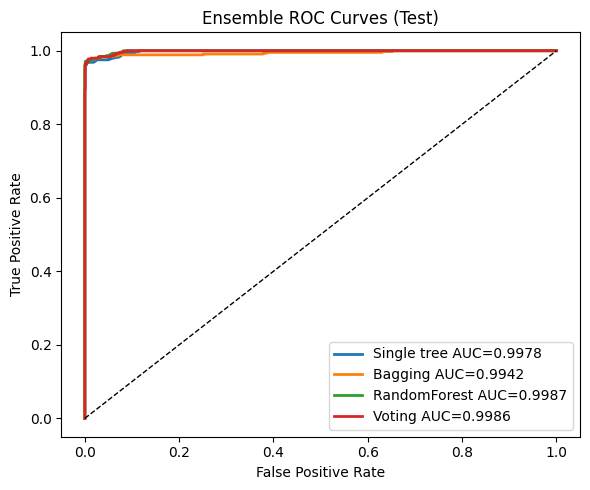

In [5]:
plt.figure(figsize=(6, 5))
for name, model_obj, _ in results:
    if model_obj is None or not hasattr(model_obj, 'predict_proba'):
        continue
    probs = model_obj.predict_proba(X_test)[:, 1]
    fpr, tpr, auc = roc_auc_from_scores(y_test, probs)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} AUC={auc:.4f}')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble ROC Curves (Test)')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Regression Ensemble (`num_legal_moves`)

The regression task predicts the actual number of legal moves. We compare the random forest regressor against a mean predictor so the ensemble has a simple reference point, then visualize predicted versus actual values.

In [6]:
y_target = y_reg
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_target[train_idx], y_target[test_idx]

print('Train samples:', X_train.shape[0], '| Test samples:', X_test.shape[0])


Train samples: 6400 | Test samples: 1600


Regression comparison (test)
------------------------------------------------------------------------
Model                             R2         MSE        RMSE         MAE
------------------------------------------------------------------------
Mean baseline                -0.0007      1.0652      1.0321      0.7904
RandomForestRegressor         0.9593      0.0433      0.2080      0.1243
------------------------------------------------------------------------


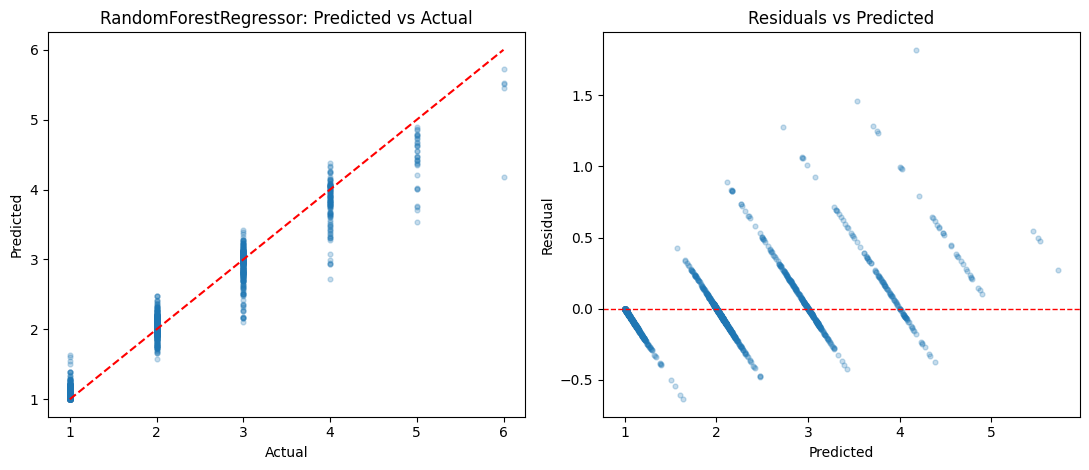

In [7]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = float(np.mean((y_true - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    return {'r2': r2, 'mse': mse, 'rmse': rmse, 'mae': mae}

mean_pred = np.full_like(y_test, fill_value=float(y_train.mean()), dtype=float)
mean_metrics = regression_metrics(y_test, mean_pred)

rf_reg = RandomForestRegressor(n_estimators=20, max_depth=9, min_samples_leaf=4, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred = rf_reg.predict(X_test)
rf_metrics = regression_metrics(y_test, y_pred)

print('Regression comparison (test)')
print('-' * 72)
print(f"{'Model':<26}{'R2':>10}{'MSE':>12}{'RMSE':>12}{'MAE':>12}")
print('-' * 72)
for name, metrics in [('Mean baseline', mean_metrics), ('RandomForestRegressor', rf_metrics)]:
    print(f"{name:<26}{metrics['r2']:>10.4f}{metrics['mse']:>12.4f}{metrics['rmse']:>12.4f}{metrics['mae']:>12.4f}")
print('-' * 72)

residuals = y_test - y_pred
fig, ax = plt.subplots(1, 2, figsize=(11, 4.8))

ax[0].scatter(y_test, y_pred, alpha=0.25, s=12)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax[0].plot(lims, lims, 'r--')
ax[0].set_xlabel('Actual')
ax[0].set_ylabel('Predicted')
ax[0].set_title('RandomForestRegressor: Predicted vs Actual')

ax[1].scatter(y_pred, residuals, alpha=0.25, s=12)
ax[1].axhline(0, color='r', linestyle='--', linewidth=1)
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Residual')
ax[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()


## 5. Conclusion

The ensemble workflow gives a fuller comparison than a single model score. The majority baseline sets the floor, the single tree shows what one nonlinear learner can do, and bagging/random forests test whether averaging many trees improves stability. Voting adds a different inductive bias by combining a tree with a distance-based classifier.

For Brainvita, these methods are especially appropriate because legal-move availability depends on interactions between peg density, local jump structure, clusters, and reachability. The random forest regressor extends the same idea to the raw legal-move count, giving a nonlinear benchmark to compare against the OLS notebook.
